In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:

tsla = pd.read_csv("../data/raw/TSLA.csv")
spy = pd.read_csv("../data/raw/SPY.csv")
bnd = pd.read_csv("../data/raw/BND.csv")

# Convert Date column to datetime
for df in [tsla, spy, bnd]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)

In [14]:
prices = pd.concat(
    [
        tsla["Close"],
        spy["Close"],
        bnd["Close"],
    ],
    axis=1
)

prices.columns = ["TSLA", "SPY", "BND"]

print(prices.index)
print(prices.head())

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24',
               '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30',
               '2026-07-01', '2026-07-02'],
              dtype='datetime64[ns]', name='Date', length=2891, freq=None)
                 TSLA         SPY        BND
Date                                        
2015-01-02  14.620667  169.687836  59.205635
2015-01-05  14.006000  166.623352  59.377613
2015-01-06  14.085333  165.053879  59.549477
2015-01-07  14.063333  167.110703  59.585312
2015-01-08  14.041333  170.076065  59.492199


In [15]:
returns = prices.pct_change().dropna()

returns = returns.loc["2025-01-01":"2026-01-01"]

returns.head()

,TSLA,SPY,BND
Date,,,
2025-01-02,-0.060816,-0.002457,0.000417
2025-01-03,0.082156,0.012503,-0.001251
2025-01-06,0.001486,0.005761,-0.000974
2025-01-07,-0.040603,-0.011304,-0.003483
2025-01-08,0.001471,0.001461,0.001118


In [21]:
print(strategy_returns.head())
print(strategy_returns.tail())

print("Length:", len(strategy_returns))
print("Std:", strategy_returns.std())

Date
2025-01-02   -0.018528
2025-01-03    0.026522
2025-01-06    0.001111
2025-01-07   -0.016183
2025-01-08    0.001293
dtype: float64
Date
2025-12-24    0.001821
2025-12-26   -0.006331
2025-12-29   -0.009789
2025-12-30   -0.003847
2025-12-31   -0.005938
dtype: float64
Length: 250
Std: 0.013930462916029318


In [16]:
print(returns.shape)
print(returns.head())
print(returns.tail())

strategy_weights = np.array([
    0.30,
    0.20,
    0.50
])

benchmark_weights = np.array([
    0.00,
    0.60,
    0.40
])

(250, 3)
                TSLA       SPY       BND
Date                                    
2025-01-02 -0.060816 -0.002457  0.000417
2025-01-03  0.082156  0.012503 -0.001251
2025-01-06  0.001486  0.005761 -0.000974
2025-01-07 -0.040603 -0.011304 -0.003483
2025-01-08  0.001471  0.001461  0.001118
                TSLA       SPY       BND
Date                                    
2025-12-24 -0.000330  0.003518  0.002432
2025-12-26 -0.021034 -0.000101  0.000000
2025-12-29 -0.032724 -0.003564  0.001483
2025-12-30 -0.011335 -0.001221 -0.000404
2025-12-31 -0.010365 -0.007409 -0.002693


In [17]:
strategy_returns = returns.dot(strategy_weights)

benchmark_returns = returns.dot(benchmark_weights)

In [23]:
strategy_cumulative = (1 + strategy_returns).cumprod()

benchmark_cumulative = (1 + benchmark_returns).cumprod()
print(strategy_cumulative.head())
print(strategy_cumulative.tail())

Date
2025-01-02    0.981472
2025-01-03    1.007503
2025-01-06    1.008622
2025-01-07    0.992299
2025-01-08    0.993582
dtype: float64
Date
2025-12-24    1.178978
2025-12-26    1.171514
2025-12-29    1.160047
2025-12-30    1.155585
2025-12-31    1.148723
dtype: float64


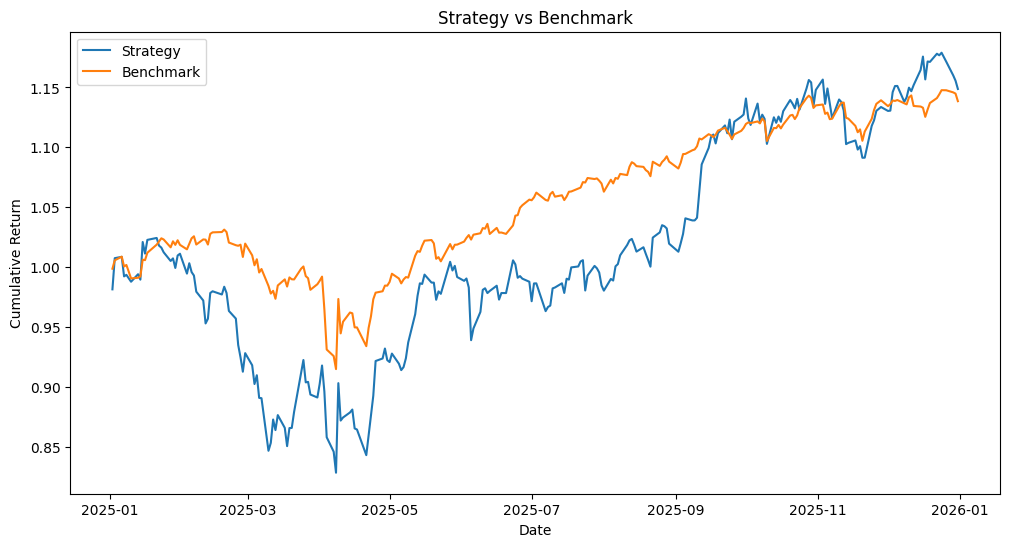

In [19]:
plt.figure(figsize=(12,6))

plt.plot(strategy_cumulative, label="Strategy")

plt.plot(benchmark_cumulative, label="Benchmark")

plt.title("Strategy vs Benchmark")

plt.xlabel("Date")

plt.ylabel("Cumulative Return")

plt.legend()

plt.show()

In [24]:
import numpy as np

def total_return(cumulative):
    return cumulative.iloc[-1] - 1


def annual_return(daily_returns):
    return (1 + daily_returns).prod() ** (252 / len(daily_returns)) - 1


def sharpe_ratio(daily_returns, rf=0):
    excess = daily_returns - rf / 252
    std = excess.std()

    if std == 0 or np.isnan(std):
        return np.nan

    return np.sqrt(252) * excess.mean() / std


def max_drawdown(cumulative):
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()

In [25]:
results = pd.DataFrame({
    "Portfolio": ["Strategy", "Benchmark"],
    "Total Return": [
        total_return(strategy_cumulative),
        total_return(benchmark_cumulative),
    ],
    "Annual Return": [
        annual_return(strategy_returns),
        annual_return(benchmark_returns),
    ],
    "Sharpe Ratio": [
        sharpe_ratio(strategy_returns),
        sharpe_ratio(benchmark_returns),
    ],
    "Maximum Drawdown": [
        max_drawdown(strategy_cumulative),
        max_drawdown(benchmark_cumulative),
    ],
})

results

,Portfolio,Total Return,Annual Return,Sharpe Ratio,Maximum Drawdown
0,Strategy,0.148723,0.149998,0.741594,-0.191297
1,Benchmark,0.138525,0.139707,1.150873,-0.112888
